In [1]:
# Reset e imports
%reset -f
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from sklearn.model_selection import TimeSeriesSplit
import re


In [13]:
b = bagreader( 'MAC_aguas_claras_2025-01-21-12-07-24_0.bag' )
# print(b.start_time)
# print('Vídeo: Início da gravação (est) em 01:42')
# print('Vídeo: Início das "perdas de pacote" (est) em 27:42')
# print('Vídeo: Parada em 27:53 (1673) - 29:37 (1777): delta = 100')
# print('Telemetria: Parada em 29:41 (1781.361) - 32:51 (1971.154): delta = 190')
# print('Vídeo: Reset em 29:03')
# print('Vídeo: Reset em 45:10')
# print(1737451740-b.start_time)
# print(b.start_time-108.361)

[INFO]  Data folder MAC_aguas_claras_2025-01-21-12-07-24_0 already exists. Not creating.
1737472044.637148
Vídeo: Início da gravação (est) em 01:42
Vídeo: Início das "perdas de pacote" (est) em 27:42
Vídeo: Parada em 27:53 (1673) - 29:37 (1777): delta = 100
Telemetria: Parada em 29:41 (1781.361) - 32:51 (1971.154): delta = 190
Vídeo: Reset em 29:03
Vídeo: Reset em 45:10
-20304.637147903442
1737471936.2761478


C:\Users\leoki\AppData\Local\Temp\ipykernel_5876\1212338557.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')


1981

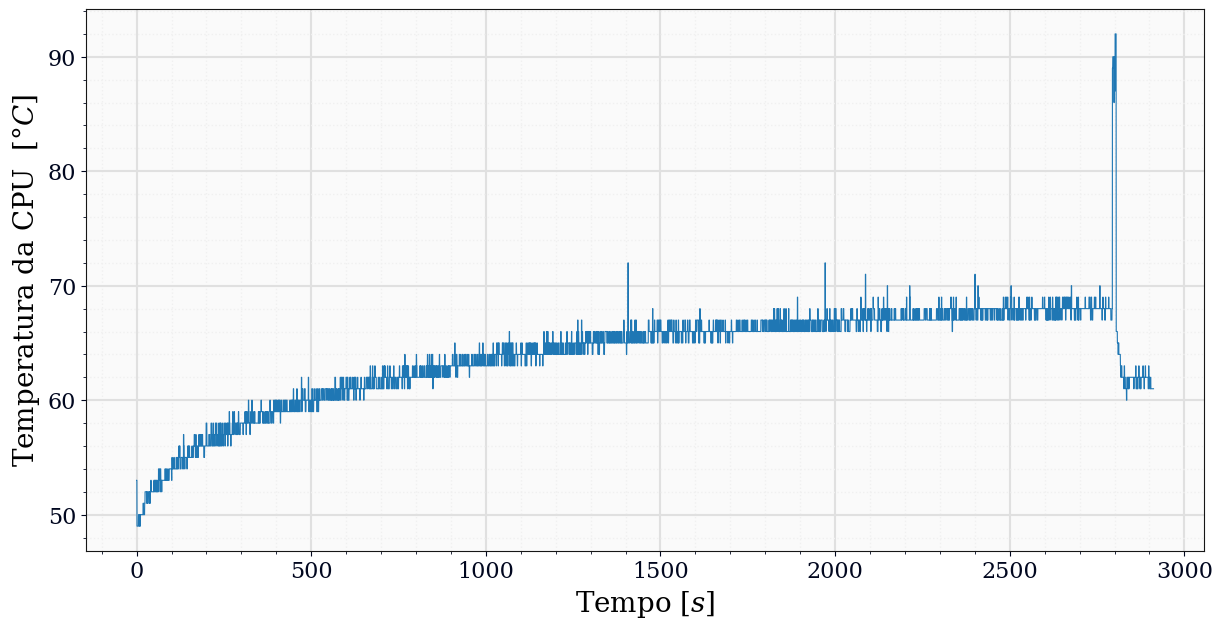

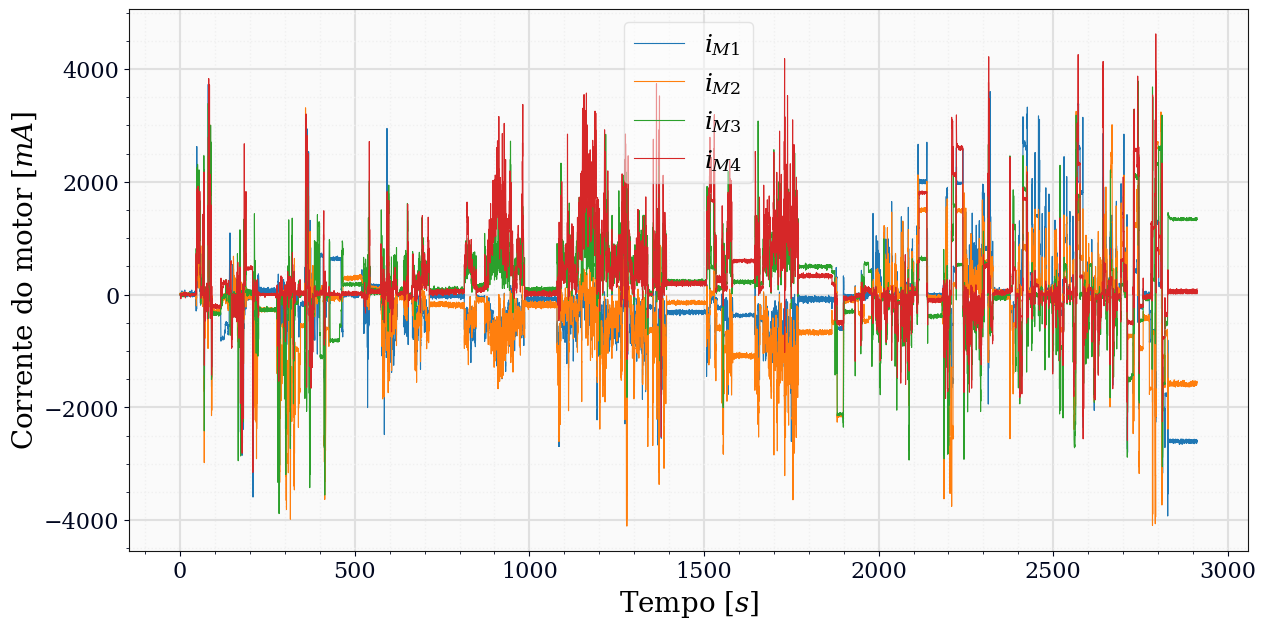

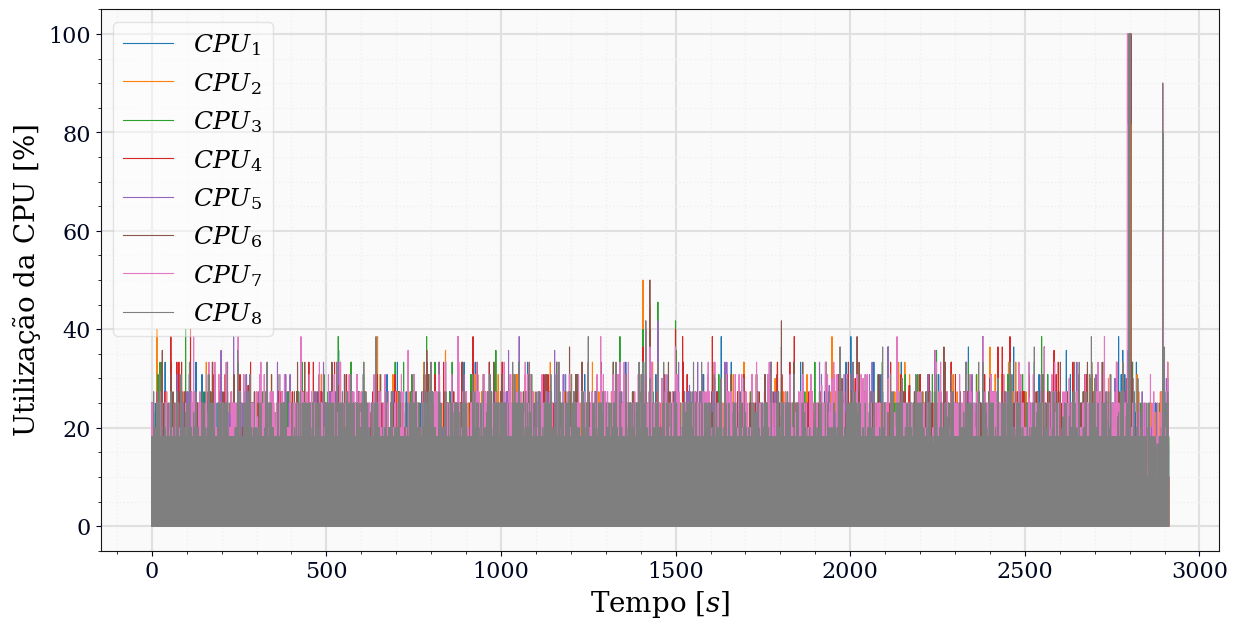

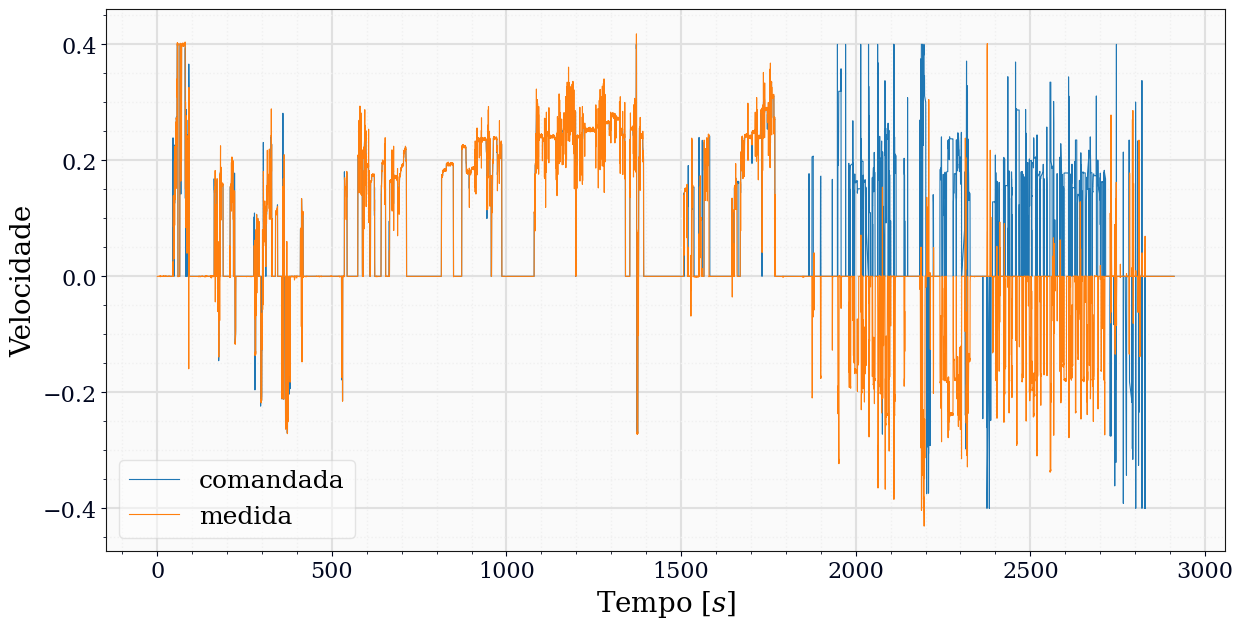

In [3]:
# Cria a variável "telemetria" a partir da bag selecionada acima


# ===================== Desembaraça as mensagens salvas na bag =====================
# Temperatura da CPU
aux1 = b.message_by_topic('/cpu_temp')
aux1 = pd.read_csv(aux1)
aux1 = aux1.rename(columns={'data': 'T_CPU'})
aux1.Time = aux1.Time - b.start_time

# # Corrente instantânea da bateria 1
# aux2 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux2 = pd.read_csv(aux2)
# aux2 = aux2.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux2 = aux2.rename(columns={'data_1': 'i_B1'})
# aux2.i_B1=-aux2.i_B1
# aux2.Time = aux2.Time - b.start_time

# # Corrente média da bateria 1
# aux3 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux3 = pd.read_csv(aux3)
# aux3 = aux3.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux3 = aux3.rename(columns={'data_2': 'i_B1_avg'})
# aux3.i_B1_avg=-aux3.i_B1_avg
# aux3.Time = aux3.Time - b.start_time

# # Corrente instantânea da bateria 2
# aux4 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux4 = pd.read_csv(aux4)
# aux4 = aux4.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux4 = aux4.rename(columns={'data_1': 'i_B2'})
# aux4.i_B2=-aux4.i_B2
# aux4.Time = aux4.Time - b.start_time

# # Corrente média da bateria 2
# aux5 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux5 = pd.read_csv(aux5)
# aux5 = aux5.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux5 = aux5.rename(columns={'data_2': 'i_B2_avg'})
# aux5.i_B2_avg=-aux5.i_B2_avg
# aux5.Time = aux5.Time - b.start_time

# Corrente no motor 1
aux6 = b.message_by_topic('/device1/get_current_actual_value')
aux6 = pd.read_csv(aux6)
aux6 = aux6.rename(columns={'data': 'i_M1'})
aux6.Time = aux6.Time - b.start_time

# Corrente no motor 2
aux7 = b.message_by_topic('/device3/get_current_actual_value')
aux7 = pd.read_csv(aux7)
aux7 = aux7.rename(columns={'data': 'i_M2'})
aux7.Time = aux7.Time - b.start_time

# Corrente no motor 3
aux8 = b.message_by_topic('/device4/get_current_actual_value')
aux8 = pd.read_csv(aux8)
aux8 = aux8.rename(columns={'data': 'i_M3'})
aux8.Time = aux8.Time - b.start_time

# Corrente no motor 4
aux9 = b.message_by_topic('/device6/get_current_actual_value')
aux9 = pd.read_csv(aux9)
aux9 = aux9.rename(columns={'data': 'i_M4'})
aux9.Time = aux9.Time - b.start_time

# # Intensidade dos LEDs frontais
# aux10 = b.message_by_topic('/espeleo_io/frontLight')
# aux10 = pd.read_csv(aux10)
# aux10 = aux10.drop(['chooseLight'],axis=1)
# aux10 = aux10.rename(columns={'intensityLight': 'LED_F'})
# aux10.Time = aux10.Time - b.start_time

# # Intensidade dos LEDs traseiros
# aux11 = b.message_by_topic('/espeleo_io/backLight')
# aux11 = pd.read_csv(aux11)
# aux11 = aux11.drop(['chooseLight'],axis=1)
# aux11 = aux11.rename(columns={'intensityLight': 'LED_B'})
# aux11.Time = aux11.Time - b.start_time

# Porcentagem de utilizacao da CPU
aux12=b.message_by_topic('/cpu_percent')
aux12=pd.read_csv(aux12)
aux12.rename(columns=lambda col: re.sub(r'^data_(\d+)$', r'CPU_\1', col), inplace=True)
aux12.drop(['layout.dim','layout.data_offset'],axis=1,inplace=True)
aux12.Time = aux12.Time - b.start_time

# Resolve o número de CPUs
NumCPUs=len(aux12.columns)-1    # Se for rodado depois de retirar colunas de layout


aux13 = b.message_by_topic('/cmd_vel')
aux13 = pd.read_csv(aux13)
aux13.drop(['linear.y','linear.z','angular.x','angular.y','angular.z'],axis=1,inplace=True)
aux13 = aux13.rename(columns={'linear.x': 'cmd_vel'})
aux13.Time = aux13.Time - b.start_time

aux14 = b.message_by_topic('/robot_vel')
aux14 = pd.read_csv(aux14)
aux14 = aux14.rename(columns={'linear.x': 'robot_vel'})
aux14.drop(['linear.y','linear.z','angular.x','angular.y','angular.z'],axis=1,inplace=True)
aux14.Time = aux14.Time - b.start_time

# Monta um DataFrame consolidando todas as variáveis
# telemetria=pd.merge_ordered(aux1,aux2,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux3,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux4,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux5,on='Time',how='outer')
telemetria=pd.merge_ordered(aux1,aux6,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux7,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux8,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux9,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux10,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux11,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux12,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux13,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux14,on='Time',how='outer')
telemetria=telemetria.set_index('Time')


# ========================================== Limpa o DataFrame ==========================================
# Preenche os valores NaN com interpolação linear ou ZOH conforme o que faz mais sentido para cada variável.
telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')
# telemetria.i_B1=telemetria.i_B1.interpolate(method='linear')
# telemetria.i_B1_avg=telemetria.i_B1_avg.interpolate(method='linear')
# telemetria.i_B2=telemetria.i_B2.interpolate(method='linear')
# telemetria=telemetria.rename(columns={'i_B2_x': 'i_B2'})
# telemetria.i_B2_avg=telemetria.i_B2_avg.interpolate(method='linear')
telemetria.i_M1=telemetria.i_M1.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M1_x': 'i_M1'})
telemetria.i_M2=telemetria.i_M2.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M2_x': 'i_M2'})
telemetria.i_M3=telemetria.i_M3.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M3_x': 'i_M3'})
telemetria.i_M4=telemetria.i_M4.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M4_x': 'i_M4'})
# telemetria.LED_F=telemetria.LED_F.fillna(method='ffill').fillna(0)
# telemetria.LED_F=telemetria.LED_F
# telemetria.LED_B=telemetria.LED_B.fillna(method='ffill').fillna(0)
# telemetria.LED_B=telemetria.LED_B.fillna(0)
for CPU in range(NumCPUs):     telemetria[f'CPU_{CPU}']=telemetria[f'CPU_{CPU}'].interpolate(method='linear')
telemetria.cmd_vel=telemetria.cmd_vel.interpolate(method='linear')
telemetria.robot_vel=telemetria.robot_vel.interpolate(method='linear')
# telemetria=telemetria.dropna()

# Salva em arquivo do excel
telemetria.to_excel('telemetria.xlsx')
# Limpa variáveis desnecessárias
# del aux1, aux2, aux3, aux4, aux5, aux6, aux7, aux8, aux9, aux10, aux11, aux12
del aux1, aux6, aux7, aux8, aux9, aux12, aux13, aux14
gc.collect()

# ===================== Plota a telemetria extraída da bag e a média móvel da temperatura da CPU =====================
fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,       linewidth=0.8)
ax.set_ylabel('Temperatura da CPU  '+r'$[°C]$')
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryTemperature.svg", format='svg')

# ax[1].plot('i_B1',      data = telemetria,	  label = r'$i_{B1}$',                linewidth=0.8)
# ax[1].plot('i_B2',      data = telemetria,      label = r'$i_{B2}$',                linewidth=0.8)
# ax[1].plot('i_B1_avg',  data = telemetria,      label = r'$\overline{i}_{B1}$',     linewidth=2)
# ax[1].plot('i_B2_avg',  data = telemetria,      label = r'$\overline{i}_{B2}$',     linewidth=2)
# ax[1].set_ylabel('Corrente da bateria '+r'$[mA]$')
fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('i_M1',      data = telemetria,      label = r'$i_{M1}$',                linewidth=0.8)
ax.plot('i_M2',      data = telemetria,      label = r'$i_{M2}$',                linewidth=0.8)
ax.plot('i_M3',      data = telemetria,      label = r'$i_{M3}$',                linewidth=0.8)
ax.plot('i_M4',      data = telemetria,      label = r'$i_{M4}$',                linewidth=0.8)
ax.set_ylabel('Corrente do motor '+r'$[mA]$')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryMotors.svg", format='svg')

# ax[3].plot('LED_F',     data = telemetria,      label = r'$LED_{F}$',               linewidth=2, alpha=0.7)
# ax[3].plot('LED_B',     data = telemetria,      label = r'$LED_{B}$',               linewidth=2, alpha=0.7)
# ax[3].set_ylabel('Carga '+r'$[\%]$')
fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=0.8)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_ylabel('Utilização da CPU '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryCPU.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('cmd_vel',      data = telemetria,      label = 'comandada',                linewidth=0.8)
ax.plot('robot_vel',      data = telemetria,      label = 'medida',                linewidth=0.8)
ax.set_ylabel('Velocidade')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryVel.svg", format='svg')

del ax, fig
gc.collect()

In [4]:
#   Parâmetros para configuração do processamento de dados 
Window_temp=10          # Tamanho da janela usada para calcular a média móvel da T_CPU
Window_mot=10           # Tamanho da janela usada para calcular a média móvel das correntes dos motores
NumBuckets=10           # Em quantos buckets dividir a grandeza "dissipação"

#   Parâmetros para treinamento do modelo
target=['T_CPU']
features=[
            #'T_CPU',
            #'i_B1','i_B1_avg','i_B2','i_B2_avg',
            #'i_M1','i_M2','i_M3','i_M4',
            'T_CPU_trend',# 'T_CPU_detrend',
            'CPU_0','CPU_1','CPU_2','CPU_3','CPU_4','CPU_5','CPU_6','CPU_7',
            # 'LED_F', 'LED_B',
            # 'Dissip_B1','Dissip_B2',
            'Dissip_M1','Dissip_M2','Dissip_M3','Dissip_M4',
            'Dissip_CPU',
            #'T_CPU_lag'
          ]


# Parâmetros para validação cruzada
NumFolds=5
TamTeste=20000
GapTeste=500

In [ ]:
# Processamento de dados


# ======= Cria ou sobreescreve df para receber os cálculos =======
df=telemetria[target]
for f in features:
    if f in telemetria.columns: 
        df=df.merge(telemetria[f],left_index=True,right_index=True)
        


# ===================== Calcula a média móvel da temperatura da CPU =====================
trend=df[target].rolling(Window_temp).sum()/Window_temp                                 # Calcula a média móvel
df=df.merge(trend.rename(columns={'T_CPU':'T_CPU_trend'}),left_index=True, right_index=True)      # Acrescenta ao DataFrame


# Gera o feature "Dissipação" (quadrado da corrente, dividido em buckets conforme o valor)
# para cada corrente medida
# Calcula a "dissipação" devido às correntes
# diss_B1 = (telemetria['i_B1']/1000)**2 
# diss_B2 = (telemetria['i_B2']/1000)**2 
diss_M1 = (telemetria['i_M1']/1000)**2 
diss_M2 = (telemetria['i_M2']/1000)**2
diss_M3 = (telemetria['i_M3']/1000)**2
diss_M4 = (telemetria['i_M4']/1000)**2

# Calcula a média móvel para as dissipações nos motores
diss_M1=diss_M1.rolling(Window_mot).sum()/Window_mot
diss_M2=diss_M2.rolling(Window_mot).sum()/Window_mot
diss_M3=diss_M3.rolling(Window_mot).sum()/Window_mot
diss_M4=diss_M4.rolling(Window_mot).sum()/Window_mot


# Configura os buckets
# amplitude=max(max(diss_B1),max(diss_B2),max(diss_M1),max(diss_M2),max(diss_M3),max(diss_M4))
amplitude=max(max(diss_M1.dropna()),max(diss_M2.dropna()),max(diss_M3.dropna()),max(diss_M4.dropna()))

oom=10**math.floor(math.log10(amplitude))
BucketMax=math.ceil(amplitude/oom)*oom
BucketStep=BucketMax/NumBuckets


# Calcula a dissipação da CPU
if 'Dissip_CPU' in features: 
    diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
    for cc in range(1,NumCPUs):
        for j in range(len(telemetria)):
            diss_CPU.iloc[j]+=telemetria[f'CPU_{cc}'].iloc[j]**2
    diss_CPU=diss_CPU/NumCPUs
    df=df.merge(right=diss_CPU.rename(columns={'CPU_0':'Dissip_CPU'}), right_index=True, left_index=True)


# ================== Calcula feature para baterias e inclui no DataFrame telemetria ==================
# Bateria 1
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B1.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B1'])
#             )

# Bateria 2
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B2.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B2'])
#             )

# Motor 1
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M1.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M1'])
            )

# M2
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M2.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M2'])
            )

# M3
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M3.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M3'])
            )

# M4
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M4.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M4'])
            )


df=df.dropna()

if False:   # Plotar as variáveis dissipação individuais?   
    fig, ax = plt.subplots(figsize=(15,5))
    diss_B1.plot(ax=ax,lw=0.8)
    diss_B2.plot(ax=ax,lw=0.8)
    diss_M1.plot(ax=ax,lw=0.8)
    diss_M2.plot(ax=ax,lw=0.8)
    diss_M3.plot(ax=ax,lw=0.8)
    diss_M4.plot(ax=ax,lw=0.8)
    ax.set_facecolor('#fafafa')
    ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
    ax.grid(which='minor', color='#f0f0f0', linewidth=1)
    del fig, ax


# ================== Cria lag feature e inclui no df ==================
df['T_CPU_lag']=df['T_CPU_trend'].shift(math.floor(-Window_temp/2))


# =============== Cria a feature detrend e inclui no df ===============
df['T_CPU_detrend']=telemetria['T_CPU']-df['T_CPU_trend']


# Limpa variáveis auxiliares
# del diss_B1, diss_B2, diss_M1, diss_M2, diss_M3, diss_M4
del diss_M1, diss_M2, diss_M3, diss_M4
del amplitude, BucketMax, BucketStep, oom
gc.collect()

0

Score across folds 2.6459
Fold scores:[np.float64(3.1361700696858983), np.float64(2.5963853982764302), np.float64(2.0545699517453744), np.float64(1.9380122092209842), np.float64(3.504599818350133)]


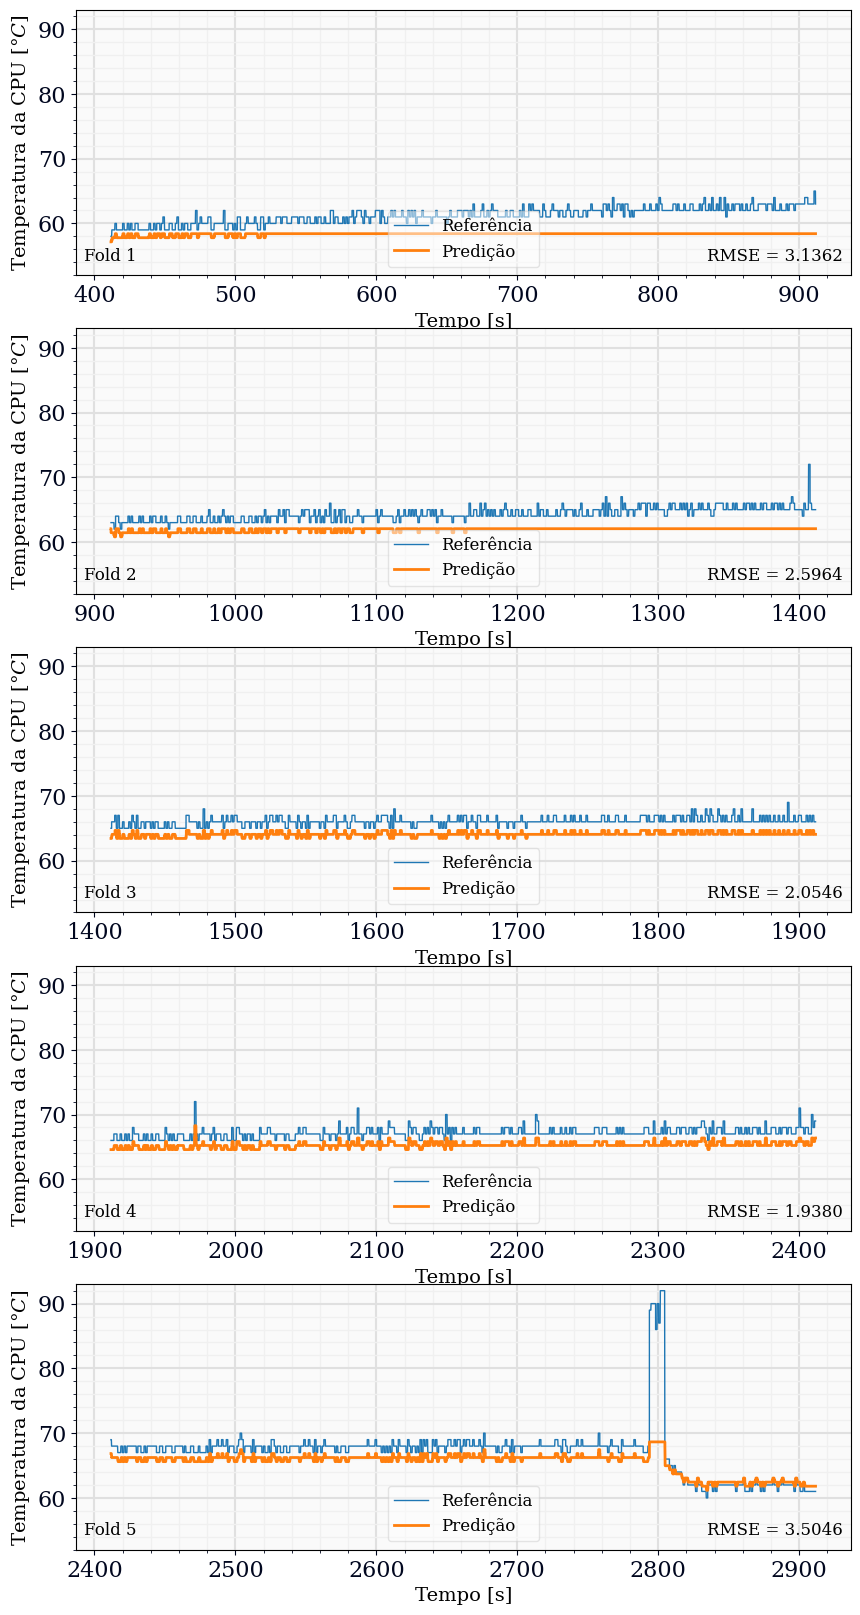

In [6]:
# Treina o modelo XGBoost e faz predições
import xgboost as xgb
from sklearn.metrics import mean_squared_error

tss = TimeSeriesSplit(n_splits=NumFolds, test_size=TamTeste, gap=GapTeste)
fig, ax = plt.subplots(nrows=NumFolds,ncols=1,figsize=(10,4*NumFolds))

fold=0
preds=[]
scores=[]
for train_idx, val_idx in tss.split(df):
        Train=df.iloc[train_idx]
        Test=df.iloc[val_idx]
        
        X_Train=Train[features]
        Y_Train=Train[target]
        X_Test=Test[features]
        Y_Test=Test[target]
        
        
        reg= xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=20, learning_rate=0.001)
        reg.fit(X_Train,Y_Train,
                eval_set=[(X_Train,Y_Train), (X_Test,Y_Test)],
                # verbose=300
                verbose=False
        )
        
        Y_Pred=reg.predict(X_Test)
        preds.append(Y_Pred)
        score=np.sqrt(mean_squared_error(Y_Test,Y_Pred))
        scores.append(score)
        ax[fold].plot('T_CPU', data=Y_Test, lw=1, label='Referência')
        ax[fold].plot(Y_Test.index,Y_Pred, lw=2, label='Predição')
        ax[fold].set_facecolor('#fafafa')
        ax[fold].grid(which='major', color='#e0e0e0', linewidth=1.5)
        ax[fold].grid(which='minor', color='#f0f0f0', linewidth=1)
        ax[fold].set_ylabel('Temperatura da CPU '+r'$[°C]$', fontsize=14)
        ax[fold].set_xlabel('Tempo [s]', fontsize=14)
        ax[fold].annotate(f'Fold {fold+1}', 
                xy=(0.01,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='left', verticalalignment='bottom')
        ax[fold].annotate(f'RMSE = {score:0.4f}',
                xy=(0.99,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='right', verticalalignment='bottom')
        ax[fold].legend(loc='lower center', fontsize=12)
        
        fold+=1
        
Y_max=max(max(telemetria['T_CPU']),max(np.concatenate(preds).ravel()))
Y_min=min(min(telemetria['T_CPU']),min(np.concatenate(preds).ravel()))
oom=10**(math.floor(math.log10(Y_max))-1)
for a in ax:
        a.set_ylim([math.floor(Y_min/oom)*oom+3,math.ceil(Y_max/oom)*oom+1])
        
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

plt.gcf().savefig("Predictions.svg",bbox_inches='tight')

C:\Users\leoki\AppData\Local\Temp\ipykernel_21784\67297499.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''])


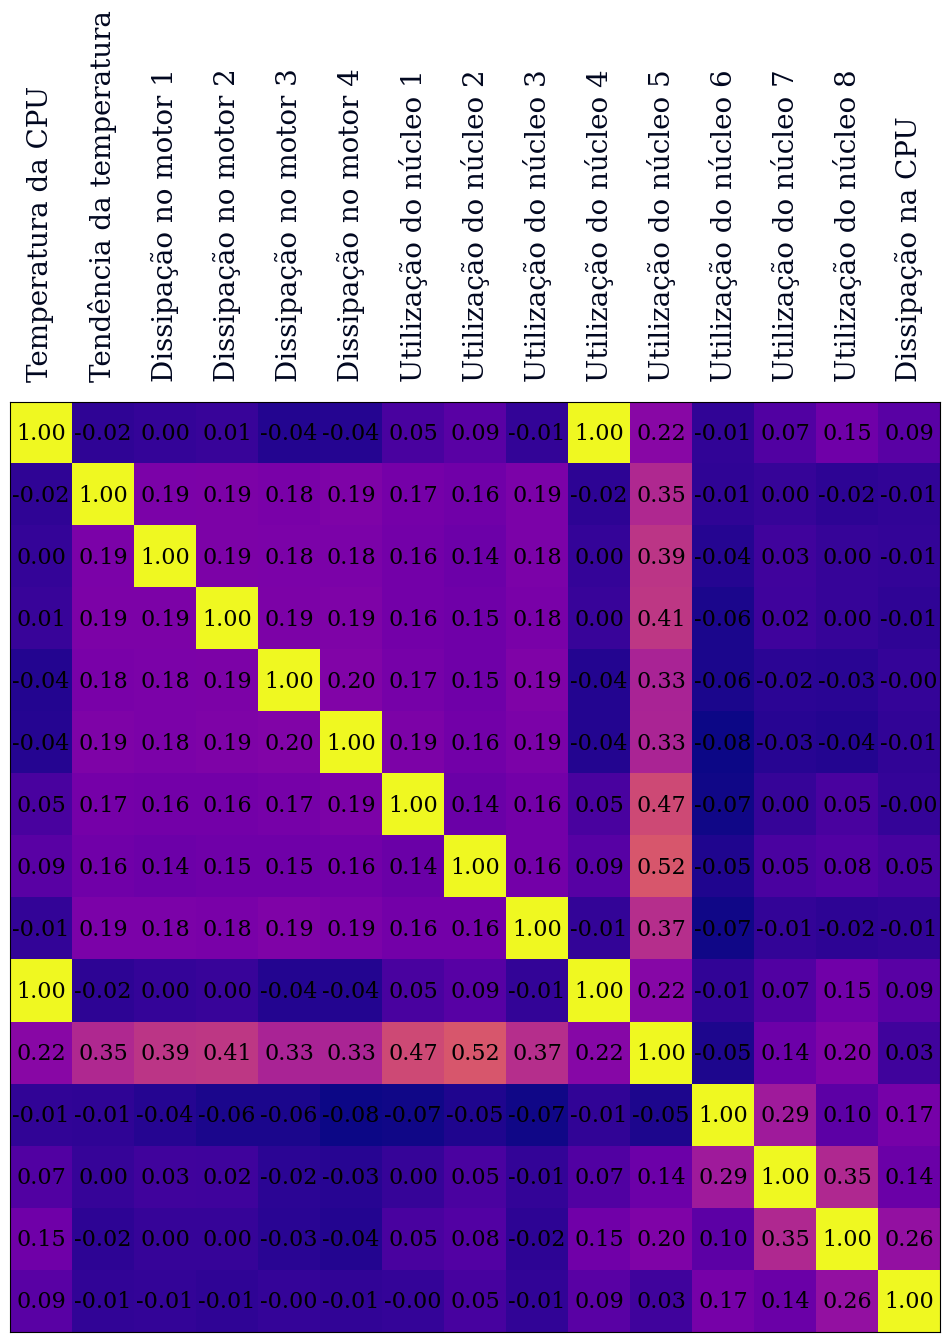

In [ ]:
# Plota a matriz de covariância
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pylab

labels=[
    'Temperatura da CPU',
    # 'Carga no LED frontal',
    # 'Carga no LED traseiro',
    'Tendência da temperatura',
    # 'Dissipação na bateria 1',
    # 'Dissipação na bateria 2',
    'Dissipação no motor 1',
    'Dissipação no motor 2',
    'Dissipação no motor 3',
    'Dissipação no motor 4',
    'Utilização do núcleo 1',
    'Utilização do núcleo 2',
    'Utilização do núcleo 3',
    'Utilização do núcleo 4',
    'Utilização do núcleo 5',
    'Utilização do núcleo 6',
    'Utilização do núcleo 7',
    'Utilização do núcleo 8',
    'Dissipação na CPU',
]
mat=df.drop(columns={'T_CPU_lag','T_CPU_detrend'}).corr()

pylab.rcParams['xtick.major.pad']='15'
ax=plt.figure().add_subplot(111)
im=ax.matshow(mat,cmap=plt.colormaps['plasma'])
N=len(mat.columns)
for cc in range(N):
    for j in range(N):
        Px=str("{n:.2f}".format(n=mat.iloc[[cc],[j]].values[0][0]))
        ax.text(cc, j, Px, va='center', ha='center',fontsize=16)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels,rotation='vertical',fontsize=20)
ax.set_yticklabels([''])
ax.tick_params(axis=u'both', which=u'both',length=0)
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.5)   
# plt.colorbar(im, cax=cax)
plt.gcf().savefig("CovMatrix.svg",bbox_inches='tight')


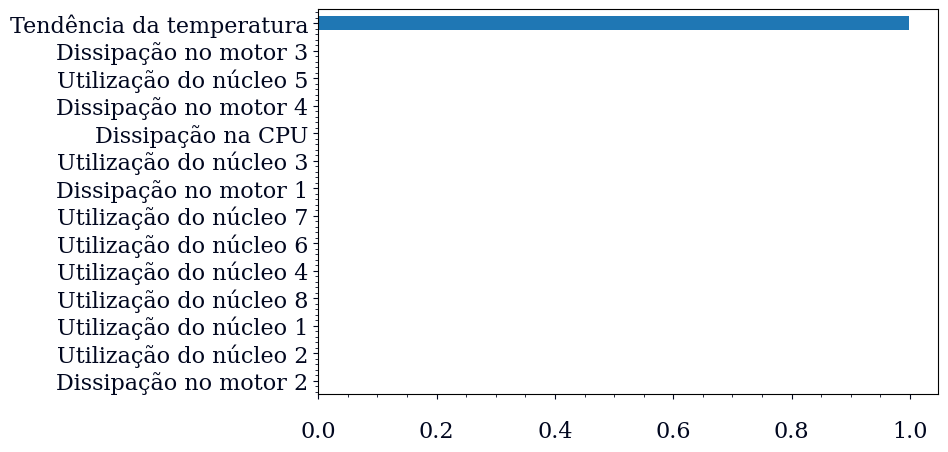

In [32]:
# Plota as importâncias relativas de cada feature
dict={
    'T_CPU_trend':'Tendência da temperatura',
    'LED_F':'Carga no LED frontal',
    'LED_B':'Carga no LED traseiro',
    'Dissip_B1':'Dissipação na batteria 1',
    'Dissip_B2':'Dissipação na batteria 2',
    'Dissip_M1':'Dissipação no motor 1',
    'Dissip_M2':'Dissipação no motor 2',
    'Dissip_M3':'Dissipação no motor 3',
    'Dissip_M4':'Dissipação no motor 4',
    'Dissip_CPU':'Dissipação na CPU',
    'CPU_0':'Utilização do núcleo 1',
    'CPU_1':'Utilização do núcleo 2',
    'CPU_2':'Utilização do núcleo 3',
    'CPU_3':'Utilização do núcleo 4',
    'CPU_4':'Utilização do núcleo 5',
    'CPU_5':'Utilização do núcleo 6',
    'CPU_6':'Utilização do núcleo 7',
    'CPU_7':'Utilização do núcleo 8'
}
fi=pd.DataFrame(index=reg.feature_names_in_, data=reg.feature_importances_, columns=['importance'])
fi=fi.sort_values('importance')
fi=fi.rename(index=dict)
fi.plot(kind='barh',figsize=(8,5))
plt.gca().get_legend().remove()
plt.gcf().savefig("ImportancePlot.svg",bbox_inches='tight')

/tmp/ipykernel_1504/1724886174.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[0].add_patch(ptc.Rectangle(xy=[t,ymin],width=-MovingAverageWindow,height=5,


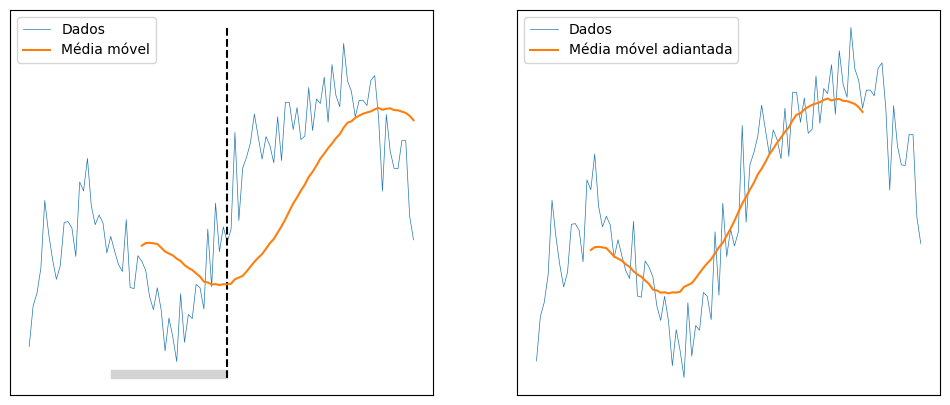

In [ ]:
# Plota um gráfico ilustrativo do procedimento de cálculo do feature T_CPU_trend
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import random
import math
Layer1Size=10
EscalaX=10
EscalaY=10
PreSmoothWindow=20
MovingAverageWindow=30

# Layer 1: Define a um vetor base manualmente. Dita a forma aproximada
x1=np.array(range(Layer1Size+2))*EscalaX
y1=np.array([0,0.08618527251172858,0.29276664037142175,0.17339907077578998,0.3148968679197107,0.2636046903087258,0.3962135971001429,0.4595127291716007,0.759708333177639,0.4605307631477288,0.5453521650684118,0.5453521650684118])
y1=y1+np.random.normal(scale=0.3,size=y1.shape)
y1=y1*EscalaY
x=np.array(range(max(x1)+1))
y=np.interp(x,x1,y1)
y=np.convolve(y, np.ones(PreSmoothWindow), mode='same')

# Layer 2: Acrescenta ruído de alta frequência
x=x[0:Layer1Size*EscalaX]
y=y[0:Layer1Size*EscalaX]
y=y+np.random.normal(scale=20,size=y.shape)

# Raw data
Px=math.floor(0.75*(max(x)-MovingAverageWindow))
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(x,y,lw=0.5,label='Dados')
ymin, ymax = np.array(ax[0].get_ylim())
ax[0].add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,
                           color='lightgray',edgecolor='black',lw=1))
ax[0].plot([Px,Px],[ymin, ymax],ls='--',color='black')

# Moving average
MA=np.convolve(y, np.ones(MovingAverageWindow)/MovingAverageWindow, mode='valid')
ax[0].plot(x[MovingAverageWindow-1:x.size],MA,label='Média móvel')
ax[0].legend()
ax[0].set_xticks([])
ax[0].set_yticks([])

offset=math.floor(MovingAverageWindow/2)
ax[1].plot(x,y,lw=0.5,label='Dados')
ax[1].plot(x[MovingAverageWindow-1-offset:x.size-offset],MA,label='Média móvel adiantada')
ax[1].legend()
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.savefig("MovingAverage.svg",bbox_inches='tight')


C:\Users\leoki\AppData\Local\Temp\ipykernel_21784\2532223018.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend(fontsize=18)


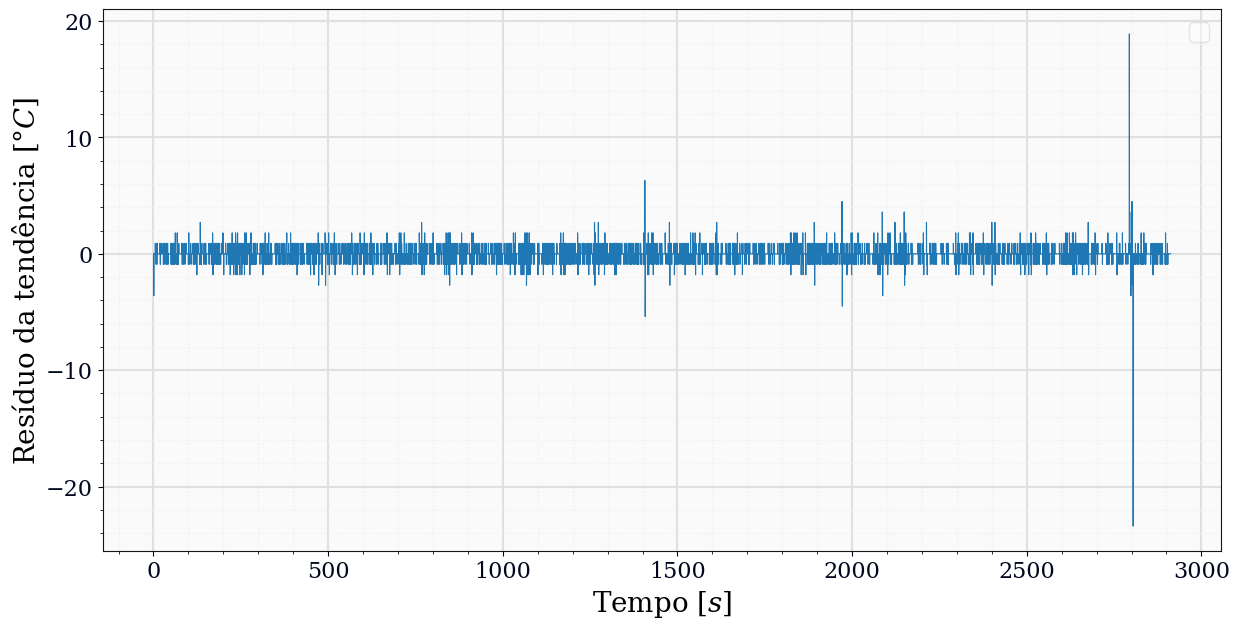

In [15]:
# Plota um gráfico da série temperatura x tempo do resíduo do detrend de T_CPU
fig, ax = bagpy.create_fig(1)
ax[0].plot('T_CPU_detrend',     data = df,      label='',       linewidth=0.8)
ax[0].set_ylabel('Resíduo da tendência '+r'$[°C]$')
for axis in ax:
    axis.legend(fontsize=18)
    axis.set_xlabel('Tempo '+r'$[s]$')
    axis.set_facecolor('#fafafa')
    axis.grid(which='major', color='#e0e0e0', linewidth=1.5)
    axis.grid(which='minor', color='#f0f0f0', linewidth=1)

plt.savefig("TempDetrend.svg",bbox_inches='tight')
plt.show()


In [ ]:
diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
for cc in range(1,NumCPUs):
    for j in range(len(telemetria)):
        diss_CPU.iloc[j]+=telemetria[f'CPU_{cc}'].iloc[j]**2
diss_CPU=diss_CPU/NumCPUs

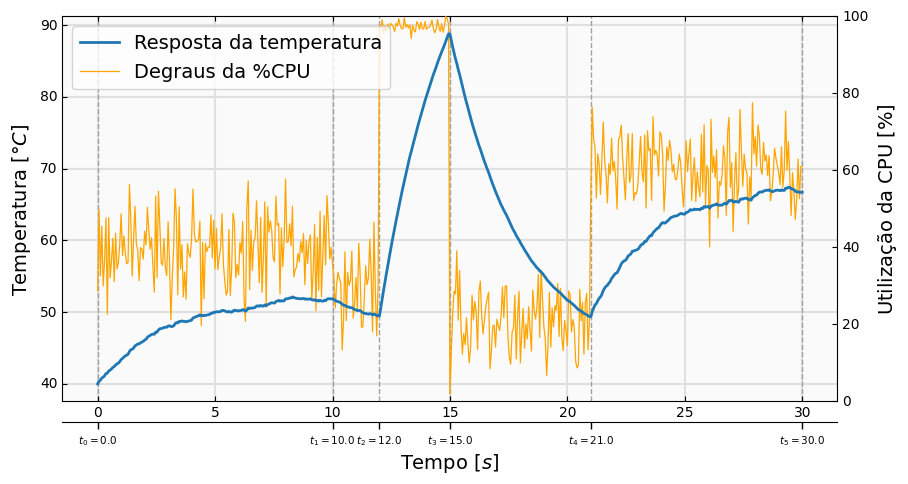

In [13]:
# Plota um gráfico ilustrativo dos trechos de tempo contendo degraus distintos da %CPU e resposta da temperatura
import numpy as np
import pandas as pd

def frange(start,stop,**kwargs):
	opcoes={'step','num'}
	arg = opcoes.intersection(kwargs.keys())
	if len(arg) != 1:
		raise ValueError("Exatamente um dos argumentos 'step' ou 'num' deve ser passado.")
		
	from math import floor, log10
	if stop<start:
		aux=stop
		stop=start
		start=aux

	arg=arg.pop()
	match arg:
		case 'step':
			step = kwargs['step']

			# Calcula a ordem de grandeza para os cálculos
			gr=10**floor(log10(step))
			# Converte os argumentos para números inteiros
			iStart=start/gr
			iStep=step/gr
			iStop=stop/gr

			# Constrói o vetor
			NumElem=floor((iStop-iStart)/iStep)+1
			array=np.zeros(NumElem)
			num=iStart
			for i in range(NumElem):
				array[i]=num*gr
				num+=iStep

			return array
		case 'num':
			num = kwargs['num'] - 1
			delta = (stop-start)/num
			
			array = start+np.array(range(num+1))*delta
			return array
def GeraVetorTempo(t, tol, MinStep, MinPontos, MaxPontos):
	"""
	Para o intervalo [min(t), max(t)], tenta encontrar um vetor de tempos com número de pontos
	variando de min_points até max_points que satisfaça:
		1. Um passo constante, com valor >= min_step.
		2. Cada valor em t apareça no vetor (dentro de tol * max(1, |ti|)).
	
	Se encontrado, 'snap' os valores para que sejam exatamente t; caso contrário, levanta um erro.
	
	Parâmetros:
		- t: lista ou array de números (em ordem crescente) que devem aparecer no vetor final.
		- min_step: valor mínimo permitido para o passo entre os pontos.
		- tol: tolerância para considerar que um valor gerado é igual a um valor em t.
		- min_points: número mínimo de pontos a tentar.
		- max_points: número máximo de pontos permitidos no vetor.
	"""
	# Bloco de validação dos argumentos
	if not isinstance(t, (list, tuple, np.ndarray)):
		raise ValueError("t deve ser uma lista, tupla ou numpy array.")
	if len(t) == 0:
		raise ValueError("t não pode ser vazio.")
	# Verifica se todos os elementos de t são numéricos
	for ti in t:
		if not isinstance(ti, (int, float)):
			raise ValueError("Todos os elementos em t devem ser números.")
	# Verifica se os valores de t estão em ordem crescente
	if any(t[i] > t[i+1] for i in range(len(t)-1)):
		raise ValueError("Os valores em t devem estar em ordem crescente.")
	
	if not (isinstance(MinStep, (int, float)) and MinStep > 0):
		raise ValueError("min_step deve ser um número positivo.")
	if not (isinstance(tol, (int, float)) and tol >= 0):
		raise ValueError("tol deve ser um número não negativo.")
	if not (isinstance(MinPontos, int) and MinPontos > 0):
		raise ValueError("min_points deve ser um inteiro positivo.")
	if not (isinstance(MaxPontos, int) and MaxPontos >= MinPontos):
		raise ValueError("max_points deve ser um inteiro maior ou igual a min_points.")
	if MinPontos < len(t):
		raise ValueError("min_points deve ser pelo menos o número de valores em t.")
	
	start = min(t)
	stop = max(t)
	if (stop - start) / (MinPontos - 1) < MinStep:
		raise ValueError("Parâmetros conflitantes: usando min_points pontos, o step resultante é menor que min_step.")    # Fim da validação dos argumentos

	found = False
	candidate_time_vec = None

	for n in range(MinPontos, MaxPontos + 1):
		# O passo candidato, se usarmos n pontos, seria:
		candidate_step = (stop - start) / (n - 1)
		if candidate_step < MinStep:
			# Se o step resultante for menor que o mínimo, esse candidato é inválido
			continue
		# Gera o vetor usando a opção 'num' de frange (garante exatamente n pontos)
		time_vec = frange(start, stop, num=n)
		# Verifica se cada valor em t está presente (dentro da tolerância)
		all_found = True
		for ti in t:
			if np.abs(time_vec - ti).min() > tol * max(1, abs(ti)):
				all_found = False
				break
		if all_found:
			# "Snap": força os valores que estão dentro da tolerância a serem exatamente t
			candidate_time_vec = time_vec.copy()
			for ti in t:
				idx = np.argmin(np.abs(candidate_time_vec - ti))
				if np.abs(candidate_time_vec[idx] - ti) <= tol * max(1, abs(ti)):
					candidate_time_vec[idx] = ti
			found = True
			break

	if not found:
		raise ValueError(
			f"Não foi possível encontrar um vetor de tempos que inclua todos os valores de t (dentro da tolerância {tol}) "
			f"usando entre {MinPontos} e {MaxPontos} pontos e com step >= {MinStep}."
		)
	return candidate_time_vec
def GeraDF(t,CPU,TempInicial=0,ParamsVetorTempo=None):
	# Gera um DataFrame que contém os dados listados
	if ParamsVetorTempo is None:
		ParamsVetorTempo = {'min_step': 0.1, 'tol': 1e-8, 'min_points': 50, 'max_points': 200}
	
	aux=GeraVetorTempo(t, **ParamsVetorTempo)
	df=pd.DataFrame(data={'t':aux,
						'CPU':np.zeros(len(aux)),
						'Temp':np.ones(len(aux))*TempInicial})

	# Alimenta valores do vetor CPU em df, nas posições especificadas em t
	ind = df.loc[df['t'].isin(t)].index[:len(CPU)]
	df.loc[ind, 'CPU'] = CPU[:len(ind)]

	# Preenche valores de df
	t_stop = t[-2]  # Penúltimo valor de t

	last_value = None
	for i in reversed(df.index):  # Percorre de trás para frente
		if i in ind:
			last_value = df.at[i, 'CPU']  # Atualiza o último valor encontrado
		elif last_value is not None and df.at[i, 't'] > t_stop:
			df.at[i, 'CPU'] = last_value  # Replica o valor
	last_value = None
	for i in df.index:  # Percorre do início ao fim
		if i in ind:
			last_value = df.at[i, 'CPU']  # Atualiza o último valor encontrado
		elif last_value is not None and df.at[i, 't'] <= t_stop:
			df.at[i, 'CPU'] = last_value  # Replica o valor

	df['t_mod'] = df['t']  # Cria uma nova coluna para armazenar o t ajustado
	pt_idx = 0  # Índice para percorrer o vetor Pt
	for i in range(len(df)):
		while pt_idx < len(Pt) - 1 and df.loc[i, 't'] >= Pt[pt_idx + 1]:  
			pt_idx += 1  # Atualiza o índice para o próximo intervalo
		df.loc[i, 't_mod'] = df.loc[i, 't'] - Pt[pt_idx]  # Ajusta t conforme Pt
	df.iloc[-1,-1]=df.iloc[-2,-1]+(df.iloc[-2,-1]-df.iloc[-3,-1])
	df=df.rename(columns={'t':'Timestamp'})
	df=df.set_index('Timestamp')
	df=df.rename(columns={'t_mod':'t'})
	return df
def AdicionaRuido(df,t,col,scale=1):
	ruido=np.random.normal(scale=scale, size=df[col].shape)
	col=df.columns.get_loc(col)
	for i in range(1, len(t)):  # Começamos de 1 para termos um intervalo de t[i-1] a t[i]
		start = df.index.get_loc(t[i-1])  # Índice do início do trecho
		stop = df.index.get_loc(t[i])-1  # Índice do final do trecho
		c = df.iloc[start:stop, col]
		r = ruido[start:stop]

		val = c + r
		
		val_max=max(val)
		if val_max > 1:
			idmax = val.tolist().index(val_max)
			fator_correcao = (1 - c.iloc[idmax]) / r[idmax]
		else: fator_correcao = 1
			# Aplicar o fator de correção no ruído do trecho
		df.iloc[start:stop, col] = df.iloc[start:stop, col] + r * fator_correcao
		df.iloc[start:stop, col] = df.iloc[start:stop, col].clip(lower=0)
def Simulacao(KCPU=4,KTemp=0.1,TauCPU=0.1,TauTemp=0.05):
	from math import exp
	idx=df.columns.get_loc('CPU')
	idy=df.columns.get_loc('Temp')
	idt=df.columns.get_loc('t')

	TempAmb=df.iloc[0,idy]
	DeltaT=df.index[1]-df.index[0]
	for i in range(1,len(df)):
		TempPrev=df.iloc[i-1,idy]
		t=df.iloc[i,idt]
		CPU=df.iloc[i,idx]
		DeltaTemp=TempPrev-TempAmb
		
		TempNext=TempPrev+KCPU*(CPU**2)*(1-exp(-t/TauCPU/DeltaT))-KTemp*(DeltaTemp)*(1-exp(-t/TauTemp/DeltaT))
		# df.iloc[i,idy]=Temp+(KCPU*exp(CPU)-KTemp*exp(DeltaTemp))/DeltaT   # KCPU = 0.04, KTemp = 0.00004
		
		df.iloc[i,idy]=TempNext
def Plots(t, offset_sec_axis=30, fontsize_sec_axis=12, hide_sec_axis_line=False, offset_xlabel=50, fontsize_axis_labels=20, fontsize_ticklabels=16, save=None):
	import matplotlib.pyplot as plt
	import matplotlib.ticker as mticker
	from mpl_toolkits.axes_grid1 import host_subplot
	import mpl_toolkits.axisartist as AA

	# Cria a figura e os eixos host e parasite
	plt.figure(figsize=(10, 5))
	host = host_subplot(111, axes_class=AA.Axes)
	parasite = host.twinx()
	parasite.axis["right"].toggle(all=True)		# Força a exibição do eixo direito do parasite (necessário com axisartist)
	host.set_zorder(2)							# Host (temperatura) acima
	parasite.set_zorder(1)						# Parasite (CPU) abaixo
	parasite.patch.set_visible(False)


	# Plots
	host.plot('Temp', data=df, linewidth=2, label='Resposta da temperatura', zorder=4)
	parasite.plot('CPU', data=df, linewidth=0.9, color='orange', label='Degraus da %CPU', zorder=3)


	# Eixo %CPU
	parasite.set_ylim(0, 1)
	parasite.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x*100:.0f}'))


	# Eixo X secundário para os valores de t
	secax = host.secondary_xaxis('bottom')
	secax.set_xticks(t)
	secax.spines['bottom'].set_position(('outward', offset_sec_axis))
	secax.spines['bottom'].set_visible(not hide_sec_axis_line)
	sec_tick_labels = [rf'$t_{{{i}}} = {t_val:.1f}$' for i, t_val in enumerate(t)]
	secax.set_xticklabels(sec_tick_labels, fontsize=fontsize_sec_axis)
	secax.tick_params(axis='x', length=5, width=1, labelsize=fontsize_sec_axis)
	for t_val in t:     parasite.axvline(x=t_val, color='#a0a0a0', linestyle='--', linewidth=1, zorder=2)   # Linhas verticais para cada valor de t


	# Axis labels
	host.axis["bottom"].label.set_text(r'Tempo $[s]$')
	host.axis["bottom"].label.set_fontsize(fontsize_axis_labels)
	host.axis["bottom"].label.set_pad(offset_xlabel)
	host.axis["left"].label.set_text(r'Temperatura $[°C]$')
	host.axis["left"].label.set_fontsize(fontsize_axis_labels)
	parasite.axis["right"].label.set_text(r'Utilização da CPU $[\%]$')
	parasite.axis["right"].label.set_fontsize(fontsize_axis_labels)


	# Tick labels
	host.axis["left"].major_ticklabels.set_fontsize(fontsize_ticklabels)
	host.axis["bottom"].major_ticklabels.set_fontsize(fontsize_ticklabels)
	parasite.axis["right"].major_ticklabels.set_fontsize(fontsize_ticklabels)


	# Fundo e grid
	host.set_facecolor('#fafafa')
	host.set_axisbelow(True)
	parasite.set_axisbelow(True)
	host.grid(which='major', color='#e0e0e0', linewidth=1.5)					# Major grid para o eixo X e Y do host
	host.xaxis.grid(True, which='major', color='#e0e0e0', linewidth=1.5)		# Força o grid major no eixo X do host


	# Legenda
	handles_host, labels_host = host.get_legend_handles_labels()
	handles_par, labels_par = parasite.get_legend_handles_labels()
	legend_dict = {}
	for h, l in zip(handles_host + handles_par, labels_host + labels_par):	legend_dict[l] = h
	host.legend(list(legend_dict.values()), list(legend_dict.keys()), loc='upper left', fontsize=fontsize_axis_labels)


	if save is not None: plt.savefig(save, bbox_inches='tight')
	plt.show()
	return

# Layer 1: Define os degraus de utilização da CPU e instantes limites, e constantes do sistema, simula a temperatura
Pt   = [0 ,     10,     12,     15,     21,     30  ]       # Tempos dos pontos definidos
Pcpu = [0.4,    0.3,    0.98,   0.21,   0.61,   0.61]       # %CPU dos pontos definidos

df=GeraDF(Pt,Pcpu,TempInicial=40,ParamsVetorTempo=dict(tol=0.0001,MinStep=0.01,MinPontos=501,MaxPontos=3001))
AdicionaRuido(df,Pt,'CPU',0.075)
Simulacao(KCPU=1.5,KTemp=0.020,TauCPU=0.0001,TauTemp=0.1)
Plots(Pt, hide_sec_axis_line=False, offset_sec_axis=15, fontsize_sec_axis=7.5, offset_xlabel=25, fontsize_ticklabels=10, fontsize_axis_labels=14, save="DemonstracaoTrechos.svg")

C:\Users\leoki\AppData\Local\Temp\ipykernel_7860\980720404.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,


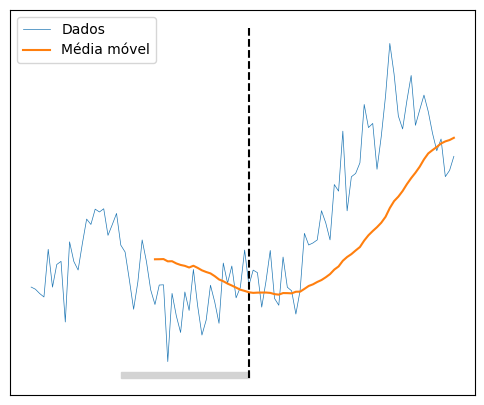

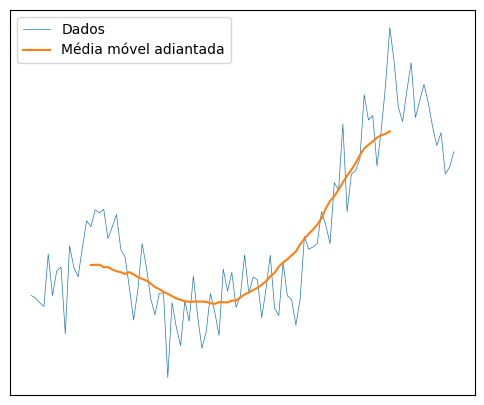

In [4]:
# Plota um gráfico ilustrativo do procedimento de cálculo do feature T_CPU_trend
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import random
import math
Layer1Size=10
EscalaX=10
EscalaY=10
PreSmoothWindow=20
MovingAverageWindow=30

# Layer 1: Define a um vetor base manualmente. Dita a forma aproximada
x1=np.array(range(Layer1Size+2))*EscalaX
y1=np.array([0,0.08618527251172858,0.29276664037142175,0.17339907077578998,0.3148968679197107,0.2636046903087258,0.3962135971001429,0.4595127291716007,0.759708333177639,0.4605307631477288,0.5453521650684118,0.5453521650684118])
y1=y1+np.random.normal(scale=0.3,size=y1.shape)
y1=y1*EscalaY
x=np.array(range(max(x1)+1))
y=np.interp(x,x1,y1)
y=np.convolve(y, np.ones(PreSmoothWindow), mode='same')

# Layer 2: Acrescenta ruído de alta frequência
x=x[0:Layer1Size*EscalaX]
y=y[0:Layer1Size*EscalaX]
y=y+np.random.normal(scale=20,size=y.shape)

# Raw data
Px=math.floor(0.75*(max(x)-MovingAverageWindow))
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.plot(x,y,lw=0.5,label='Dados')
ymin, ymax = np.array(ax.get_ylim())
ax.add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,
                           color='lightgray',edgecolor='black',lw=1))
ax.plot([Px,Px],[ymin, ymax],ls='--',color='black')

# Moving average
MA=np.convolve(y, np.ones(MovingAverageWindow)/MovingAverageWindow, mode='valid')
ax.plot(x[MovingAverageWindow-1:x.size],MA,label='Média móvel')
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
fig.savefig("MovingAverageA.svg",bbox_inches='tight')

fig, ax = plt.subplots(1,1,figsize=(6,5))
offset=math.floor(MovingAverageWindow/2)
ax.plot(x,y,lw=0.5,label='Dados')
ax.plot(x[MovingAverageWindow-1-offset:x.size-offset],MA,label='Média móvel adiantada')
ax.legend()
ax.set_xticks([])
ax.set_yticks([])

fig.savefig("MovingAverageB.svg",bbox_inches='tight')


C:\Users\leoki\AppData\Local\Temp\ipykernel_17532\2121234486.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)
C:\Users\leoki\AppData\Local\Temp\ipykernel_17532\2121234486.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig("TelemetryZoomCPU1.svg", format='svg')
C:\Users\leoki\AppData\Local\Temp\ipykernel_17532\2121234486.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


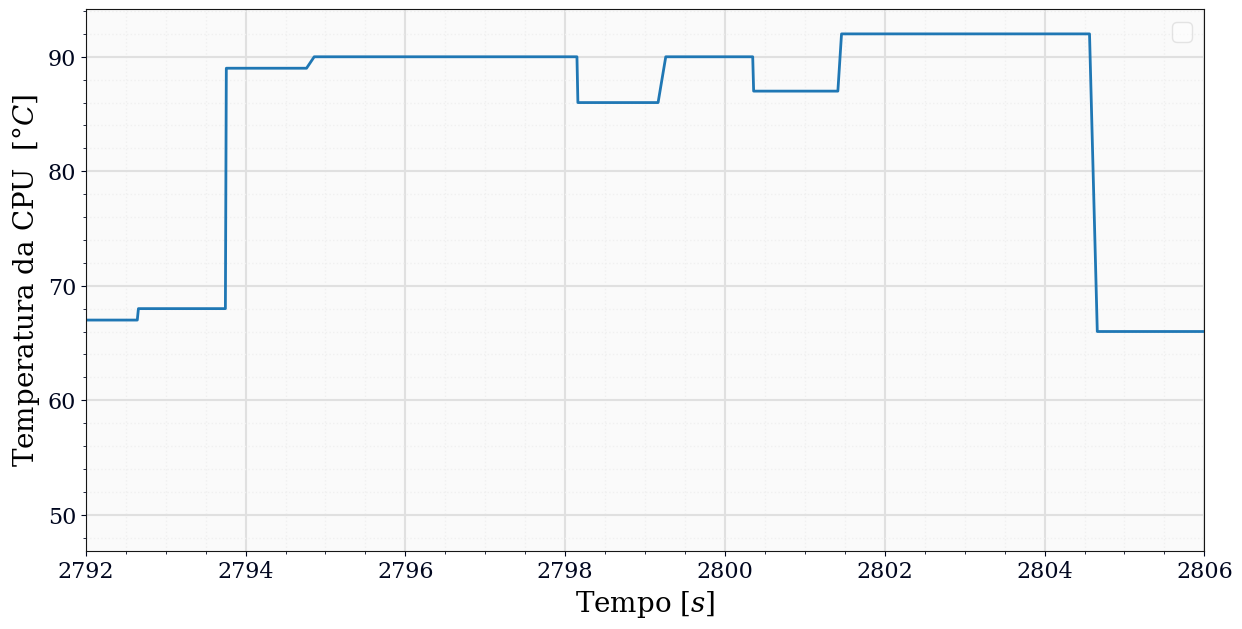

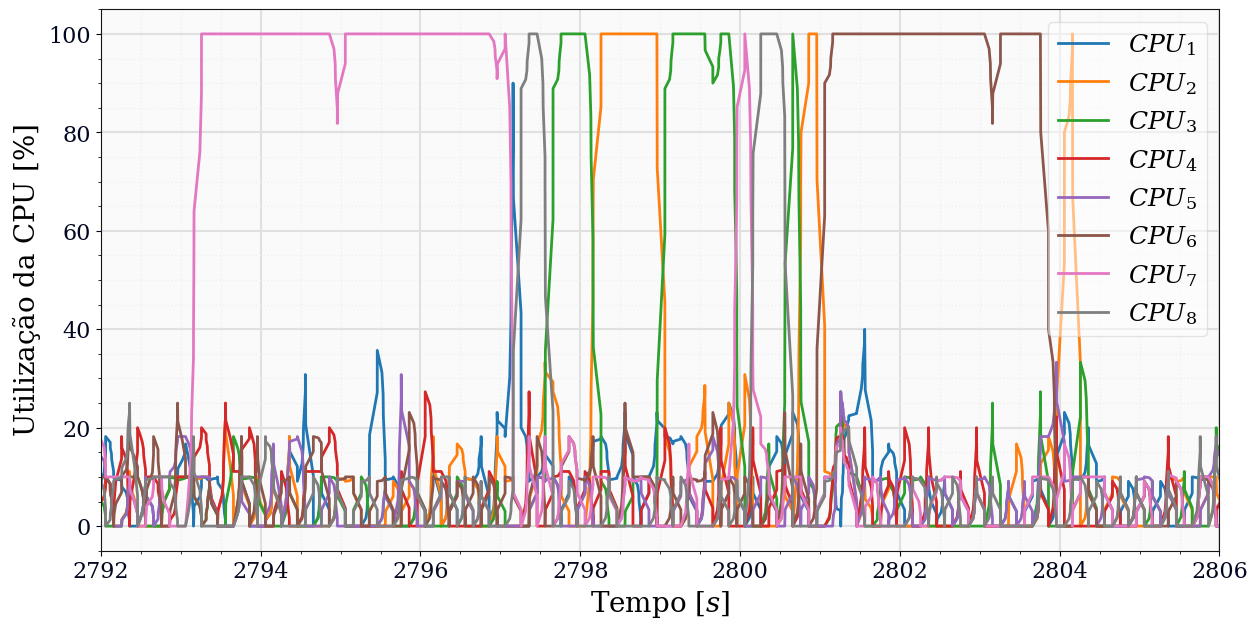

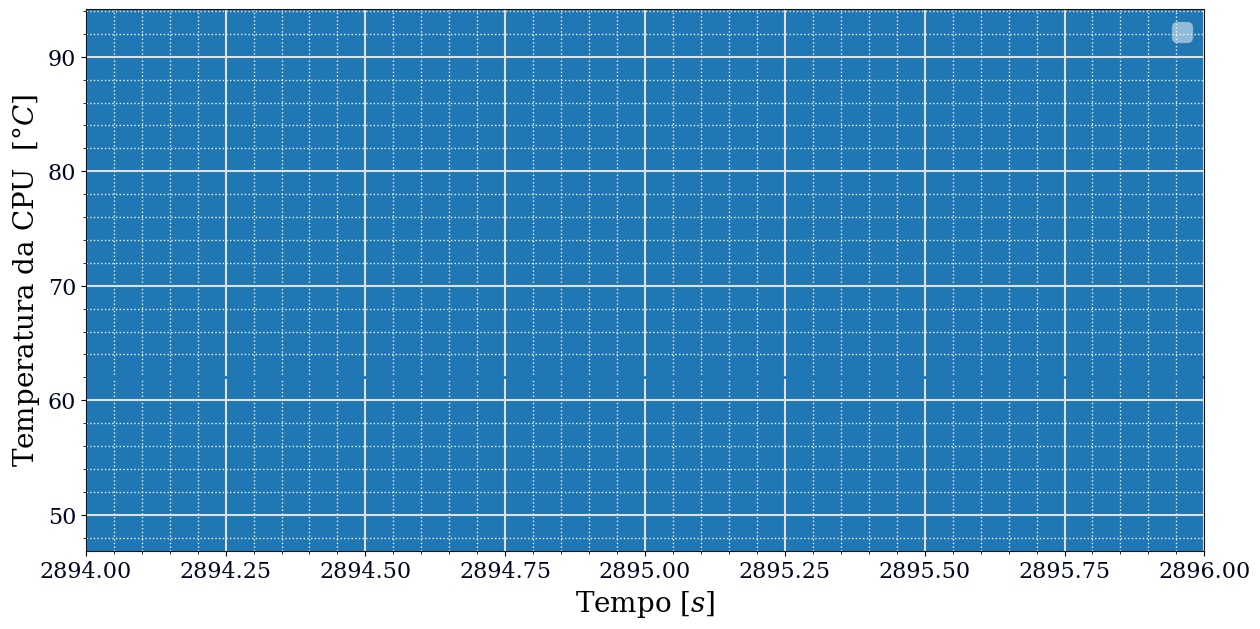

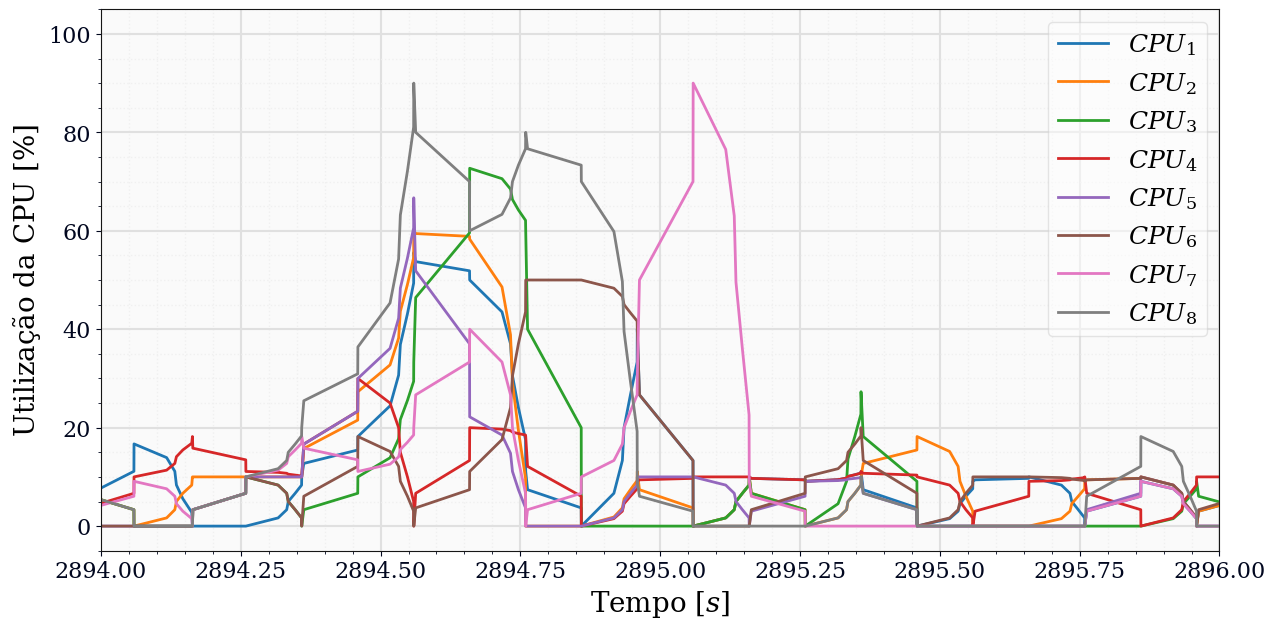

In [ ]:
# Plota gráficos com zoom em instantes de interesse da telemetria
x=[2792,2806]

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,      label = '',       linewidth=2)
ax.set_xlim(x)
ax.set_ylabel('Temperatura da CPU  '+r'$[°C]$')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomTemperature1.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=2)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_xlim(x)
ax.set_ylabel('Utilização da CPU '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomCPU1.svg", format='svg')


x=[2894,2896]

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,      label = '',       linewidth=2)
ax.set_xlim(x)
ax.set_ylabel('Temperatura da CPU  '+r'$[°C]$')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomTemperature2.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=2)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_xlim(x)
ax.set_ylabel('Utilização da CPU '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomCPU2.svg", format='svg')


In [ ]:
def gerar_telemetria_video(output, video, *telemetria, **kw):
	"""
	Gera um vídeo composto por:
		- A parte esquerda: o vídeo original (possivelmente redimensionado)
		- A parte direita: gráficos animados que exibem as telemetria empilhados verticalmente
	
	Parâmetros:
		output: string com o nome do arquivo de saída.
		video: string com o nome do arquivo de vídeo original.
		telemetria: cada telemetria pode ser:
			- Um DataFrame ou Series (que será convertido, se necessário), ou
			- Uma tupla no formato (telemetria, kwt) onde kwt é um dicionário com opções de plot.
	
	Kwargs (chaves permitidas):
		temp_dir: (opcional) diretório onde os arquivos auxiliares serão criados; se não informado, usa o diretório atual.
		atraso: (opcional) tempo (em segundos) que indica quando as telemetrias iniciam (referenciado ao instante zero do vídeo).
		span: (opcional) largura (em segundos) do eixo x dos gráficos, com 0 no centro.
		dpi: (opcional) DPI usado para gerar os gráficos.
		xlabel: (opcional) rótulo do eixo x.
		deleteaux: (opcional) se True, remove os arquivos auxiliares após a execução.
	Se forem encontrados kwargs desconhecidos, a função lançará um erro.
	"""
	# -----------------------  Tabela descritiva dos comportamentos da função para diferentes configurações de timestamps e atraso  ------------------------
	#	caso	|		timestamp_video		|		timestamp_tel		|		atraso		|	Descrição
	#			|							|							|					|
	#	1		|		não informado		|		não informado		|			0		|	Assumir tudo zero
	#	2		|		não informado		|		não informado		|	   positivo		|	Telemetria começa depois do vídeo
	#	3		|		não informado		|		não informado		|	   negativo		|	Vídeo começa depois da telemetria
	#	4		|		não informado		|		  informado			|			0		|	Assume o timestamp do vídeo igual ao da telemetria
	#	5		|		não informado		|		  informado			|	   positivo		|	Calcula o timestamp do vídeo subtraindo o atraso do timestamp da telemetria
	#	6		|		não informado		|		  informado			|	   negativo		|	Calcula o timestamp do vídeo subtraindo o atraso do timestamp da telemetria
	#	7		|		  informado			|		não informado		|			0		|	Assume o timestamp da telemetria igual ao do vídeo 
	#	8		|		  informado			|		não informado		|	   positivo		|	Calcula o timestamp da telemetria somando o atraso ao timestamp do vídeo
	#	9		|		  informado			|		não informado		|	   negativo		|	Calcula o timestamp da telemetria somando o atraso ao timestamp do vídeo
	#	10		|		  informado			|		  informado			|			0		|	Calcula o atraso total (timestamp_tel - timestamp_video + atraso informado), telemetria começa neste atraso depois do vídeo
	#	11		|		  informado			|		  informado			|	   positivo		|	Calcula o atraso total (timestamp_tel - timestamp_video + atraso informado), telemetria começa neste atraso depois do vídeo
	#	12		|		  informado			|		  informado			|	   negativo		|	Calcula o atraso total (timestamp_tel - timestamp_video + atraso informado), telemetria começa neste atraso depois do vídeo

	import os
	import ffmpeg
	import numpy as np
	import pandas as pd
	import matplotlib.pyplot as plt
	from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
	from matplotlib.colors import is_color_like as iscolor
	import warnings
	import re
	import inspect
	import time
	def calcular_largura_yticklabels(*tels, **kwargs):
		"""
		Calcula a largura máxima necessária para acomodar os yticklabels de todas as telemetrias passadas,
		considerando as configurações de fonte especificadas em plotkw (como ytick_fontsize, fontweight, fontfamily, fontstyle).
		
		Cada telemetria pode ser:
			- Um DataFrame ou Series (que será convertido se necessário), ou
			- Uma tupla no formato (telemetria, kw) onde kw é um dicionário que pode conter a chave "plotkw"
			com configurações de fonte para os yticklabels.
		
		Retorna:
			A largura máxima em pixels.
		"""
		import matplotlib.pyplot as plt
		from matplotlib.font_manager import FontProperties
		import matplotlib.backends.backend_agg as agg
		import pandas as pd
		import re
		
		kwargs=list(kwargs.items())[0][1]
		dpi=kwargs['dpi']
		max_width = 0
		fp = FontProperties()  # Propriedades padrão
		for tel in tels:
			tel=tel[0]
			if isinstance(tel, tuple): 			data = tel[0]; kw = tel[1]
			else: 								data = tel[0]; kw = {}
			if isinstance(data, pd.Series): 	data = data.to_frame()
			# Extrai configurações de fonte se existirem
			font_kwargs = {}
			if isinstance(kw, dict) and "plotkw" in kw:
				plotkw = kw["plotkw"]
				for key in ["ytick_fontsize", "fontweight", "fontfamily", "fontstyle"]:
					if key in plotkw:
						font_kwargs[key] = plotkw[key]
			if font_kwargs:
				fp = FontProperties(**font_kwargs)
			fig, ax = plt.subplots(dpi=dpi)
			if not data.empty:
				y_min = data.min().min()
				y_max = data.max().max()
				ax.set_ylim(y_min, y_max)
			else:
				ax.set_ylim(0, 1)
			fig.canvas.draw()
			canvas = agg.FigureCanvasAgg(fig)
			canvas.draw()
			renderer = canvas.get_renderer()
			pad_pts = plt.rcParams['ytick.major.pad']  # Padrão do Matplotlib
			pad_px = pad_pts * fig.dpi / 72  # Convertendo de pontos para pixels
			minus_width, _, _ = renderer.get_text_width_height_descent("−", fp, ismath=False)
			# for label in ax.get_yticklabels():
			# 	text = label.get_text()
			# 	if not text:
			# 		continue
			# 	label.set_fontproperties(fp)
			# 	bbox = label.get_window_extent(renderer=renderer)
			# 	width = bbox.width
			# 	if width > max_width:
			# 		max_width = width
			for label in ax.get_yticklabels():
				text = label.get_text()
				if not text: continue
				label.set_fontproperties(fp)
				w, _, _ = renderer.get_text_width_height_descent(text, fp, ismath=False)
				if "−" in text:  # Matplotlib usa U+2212 "−", que é diferente de hífen "-"
					w += minus_width
			width_total = w + pad_px
			if width_total > max_width:
					max_width = width_total
			plt.close(fig)
		return max_width
	def calcular_altura_xticklabels(**kwargs):
		"""
		Calcula a altura extra necessária para os xticklabels e xlabel, considerando os kwargs passados.
		"""
		kwargs=list(kwargs.items())[0][1]
		fig, ax = plt.subplots(dpi=kwargs['dpi'])
		altura_extra = 0
		
		# Verifica se xlabel está presente nos kwargs e calcula altura
		if "xlabel" in kwargs:
			label = kwargs["xlabel"] if isinstance(kwargs["xlabel"], str) else "Exemplo"
			xlabel_text = ax.set_xlabel(label)
			fig.canvas.draw()
			altura_extra += xlabel_text.get_window_extent().height / fig.dpi
		
		# Cria xticklabels fictícios para calcular a altura ocupada
		ax.set_xticks([0, 1, 2])
		ax.set_xticklabels(["0", "1", "2"])
		fig.canvas.draw()
		
		# Calcula altura máxima dos xticklabels
		ticklabel_heights = [tick.get_window_extent().height / fig.dpi for tick in ax.get_xticklabels()]
		if ticklabel_heights:
			altura_extra += max(ticklabel_heights)
		
		plt.close(fig)
		return altura_extra
	def safe_remove(filepath, retries=5, delay=0.2):
		for i in range(retries):
			try:
				os.remove(filepath)
				return
			except Exception as e:
				time.sleep(delay)
		warnings.warn(f"Não foi possível remover o arquivo {filepath} após {retries} tentativas.")
	def make_frame(tempo, *tels, **kwargs):
		"""
		Gera frames dos gráfico de telemetria:
		"""
		kwargs=list(kwargs.items())[0][1]
		tels=tels[0]
		fig, ax = plt.subplots(nrows=len(tels),
			figsize=(telemetry_area_width/kwargs["dpi"], altura/kwargs["dpi"]),
			dpi=kwargs["dpi"],
			constrained_layout=False,
			sharex=True
		)
		fig.subplots_adjust(hspace=kwargs["hspace"], **bordas_plot)  # Reduz o espaço vertical entre os gráficos
		timestamp_tel = kwargs['timestamp_tel']
		
		tt=0	# Cria o índice tt fora do for para ser acessível depois de finalizadas as iterações
		for tt, tel in enumerate(tels):
			# Extrai os argumentos em plotkw e legendkw
			kwt = tel[1];	tel=tel[0]
			legendkw = kwt["legendkw"]		# Argumentos em legendkw
			plotkw = kwt["plotkw"]			# Argumentos em plotkw
			labels = plotkw["labels"]
			coltolabel_parser = plotkw["coltolabel_parser"]			

			# Calcula a máscara de tempos para plotar no gráfico
			janela = (tel.index >= tempo - kwargs["span"]/2) & (tel.index <= tempo + kwargs["span"])
			if len(janela)==0: 				continue


			# Plota todas as colunas passadas na telemetria tel
			for cc, col in enumerate(tel.columns):
				if labels is not None:								lab = labels[cc] if cc < len(labels) else col		# Usa labels explícitos 
				elif coltolabel_parser is not None:
					if callable(coltolabel_parser):					lab = coltolabel_parser(col);					# Usa coltolabel_parser como uma função
					else: m = re.search(coltolabel_parser, col); 	lab = m.group(1) if m else col					# Usa coltolabel_parser como um regex
				else: 												lab = col										# Condição padrão, usa o nome da coluna como label

				# Calcula o valor instantâneo de col no instante 0, indicado pelo índice central de janela
				indices_janela = tel.index[janela]
				i_central = (len(indices_janela) - 1) >> 1  # Se n for ímpar, i_central aponta exatamente para o centro. Divisão inteira por 2 equivale a deslocamento de um bit para a direita
				if (len(indices_janela) & 1) == 0 and indices_janela[i_central] > tempo:	i_central -= 1	# Se n for par, i é truncado; então, se indices_janela[i] for maior que tempo, ajusta para i-1
				val = tel.loc[indices_janela[i_central], col]

				# Plota col
				ax[tt].plot(indices_janela - tempo, tel.loc[janela,col],
					label = printyvals_label(lab,val,algar[tt]), 
					**dict(filter(plotkw_filterfunc,plotkw.items()))
				)

			# Ajusta outros elementos gráficos
			ax[tt].set_ylim(	kwt["ylim"] if "ylim" in kwt.keys() 	else	[tel.min().min(),tel.max().max()]	)	 	
			ax[tt].axvline(0, color="red", linewidth=1)
			ax[tt].legend(**legendkw, fontsize=kwargs['fontsize_legend'])
			if facecolor is not None: ax[tt].set_facecolor(facecolor)
			ax[tt].grid(which='major', color='#e0e0e0', linewidth=1.5)
			ax[tt].grid(which='minor', color='#f0f0f0', linewidth=1)
			ax[tt].tick_params(axis='y', labelsize=kwargs['fontsize_ticklabel'])
		ax[tt].tick_params(axis='x', labelsize=kwargs['fontsize_ticklabel'])
		ax[tt].set_xticks(np.linspace(-kwargs["span"]/2, kwargs["span"]/2, num=5))
		ax[tt].set_xlim(-kwargs["span"]/2, kwargs["span"]/2)
		ax[tt].set_xlabel(xlabel,loc='right',fontsize=kwargs['fontsize_xlabel'])
		ax[tt].annotate(f"{timestamp_tel}  {"" if tempo<0 else "+"}{tempo:.{casasdec_tempo}f}",fontsize=kwargs['fontsize_timestamp'],
			xy=(0,0), xycoords='figure pixels',
			xytext=(0,0), textcoords='offset pixels', ha='left', va='bottom',
			bbox=dict(boxstyle='square,pad=1', fc='none', ec='none')
        )
		canvas = FigureCanvas(fig)
		canvas.draw()
		img = np.array(canvas.renderer.buffer_rgba())
		plt.close(fig)
		return img



	err = lambda msg: (_ for _ in ()).throw(ValueError(msg));	inst=isinstance
	printyvals_fmt=lambda num,tam,dec: "" if np.isnan(num) else f"{num:>{tam}.{dec}f}"	# Função de format da string para uso nas funções printyvals_...
	printyvals_label=lambda lab,val: lab						# Função que compõe a string com nome da série, e o valor instantâneo quando especificado que este seja mostrado no label.
	comp_texto_vals=[0]*len(telemetria)							# Maior comprimento da string resultante da formatação de cada telemetria, considerando todas as colunas
	algar=[0]*len(telemetria)								# Número de algarismos necessários para imprimir a parte inteira do maior número, considerando fundos de escala
	# ===========================================  Validação e tratamento de argumentos, processamentos iniciais  ==========================================
	# --------------------------------------------------------------  definição do vídeo  ------------------------------------------------------------------
	videokw={}
	if isinstance(video,tuple):
		if len(video)!=2:																	raise ValueError(f"Video: tupla deve ter exatamente 2 elementos.")
		video,videokw = video
		if not isinstance(video,str):														raise ValueError(f"Video: Quando definido em tuple, o primeiro elemento deve ser uma string com diretório/nome.")
		if not isinstance(videokw,dict):													raise ValueError(f"Video: Quando definido em tuple, o segundo elemento deve ser um dicionário.")

		videokw_copy=videokw.copy()
		args=[]
		arg = "timestamp_video";	videokw[arg] = timestamp_video = videokw.get(arg, None);		err(f"{videokw[arg]} deve ser um número") 		if not inst(videokw[arg], (int,float)) and videokw[arg] is not None			else args.append(arg)
		timestamp_video = float(timestamp_video)
		

		for arg in args: videokw_copy.pop(arg) if arg in videokw_copy else None
		if bool(videokw_copy): 																raise ValueError(f"Kwarg inesperado nos argumentos do vídeo: {list(videokw_copy)}")

	else: 
		if not isinstance(video, str):
			raise ValueError(f"Video: Quando definido em tuple, o segundo elemento deve ser um dicionário.")
		else:
			timestamp_video = None
			videokw=dict(timestamp_video=timestamp_video)
	# ------------------------------------------------------------  telemetrias e seus kwargs  -------------------------------------------------------------
	# Verificação de estruturas inesperadas e de erros no passamento da variável telemetria
	if not telemetria: 																		raise ValueError("Nenhuma telemetria foi passada.")
	aux = [];	
	for tt, tel in enumerate(telemetria):
		if not (isinstance(tel, tuple) or isinstance(tel, (pd.DataFrame, pd.Series))):		raise ValueError("Telemetrias devem ser especificadas como um DataFrame, Series ou (DataFrame/Series, dict).")
		if isinstance(tel, tuple):
			if len(tel) != 2: 																raise ValueError(f"Telemetria {tt}: tupla deve ter exatamente 2 elementos.")
			tel_data, kwt = tel
			
			if isinstance(tel_data, pd.Series): tel_data = tel_data.to_frame()		# Converte Series para DataFrame
			if not isinstance(kwt, dict):													raise ValueError(f"Telemetria {tt}: quando passado como tupla, o segundo elemento deve ser um dicionário.")
			arg = "legendkw";				kwt[arg] = legendkw = kwt.get(arg, {"ncol": len(tel_data.columns), "loc": "upper left"})
			if not (isinstance(legendkw, dict)):											raise ValueError(f"Telemetria {tt}: legendkw deve ser um dicionário.")
			arg = "plotkw";					kwt[arg] = plotkw = kwt.get(arg, {})
			if not (isinstance(plotkw, dict)):												raise ValueError(f"Telemetria {tt}: plotkw deve ser um dicionário.")
			arg = "labels";					plotkw[arg] = labels = plotkw.get(arg, None)
			arg = "coltolabel_parser";		plotkw[arg] = coltolabel_parser = plotkw.get(arg, None)
			if (labels is not None) and (coltolabel_parser is not None):
				warnings.warn(f"labels e coltolabel_parser fornecidos para a telemetria de índice {tt}. O parser será ignorado.")
				plotkw["coltolabel_parser"]=None
		else:
			tel_data = tel
			kwt = {}
		if isinstance(tel_data, pd.Series): tel_data = tel_data.to_frame()		# Converte Series para DataFrame
		aux.append((tel_data, kwt))

		# Calcula o maior número de algarismos necessários para imprimir o fundo de escala de tel
		algar[tt]=max(  [len(str(round(tel_data.min().min()))),len(str(round(tel_data.max().max())))]  )

		# Calcula o índice de tel onde ocorre o valor instantâneo que leva ao maior comprimento de string quando renderizado em texto
		id=[tel_data.idxmin().min(),tel_data.idxmax().max()]
		tam=[len(printyvals_fmt(tel_data.loc[id[0]].iloc[0],10,10)),len(printyvals_fmt(tel_data.loc[id[1]].iloc[0],10,10))]		# Usa um valor fixado de tam e dec. Qual número leva ao maior string não depende dessas quantidades
		comp_texto_vals[tt]=id[tam.index(max(tam))]
	telemetria=aux
	# Cria uma máscara para plotkw para filtrar os argumentos para a função plot. 
	# A função filter é lazy, isto é, processa chamadas quando e na medida que for 
	# requisitada, ao invés de processar todo o eval no momento da chamada. 
	plotkw_filterfunc = lambda key_value: key_value[0] in frozenset(inspect.signature(plt.plot).parameters.keys())		

	# -------------------------------------------------------------  kwargs gerais da função  -------------------------------------------------------------- 
	# Verifica e extrai valores dos kwargs. O procedimento é feito desta forma para que a extração, e a verificação de kwargs desconhecidos,
	# seja feita definindo os kwargs permitidos numa única lista estática. Para adicionar novos parâmetros execute os passos abaixo: 
	# 1: implemente a utilização do novo parâmetro no corpo da função; 2 adicione uma linha nova copiando uma já criada; 
	# 3: especifique o nome da variável como string em arg; 4: altere o nome da variável conforme implementado em 1; 5: escreva msg e condição para validação.
	# Se uma variável implicar numa inicialização, dela mesma ou de outra variável, complexa demais para a função .get(), adicione como bloco de instruções abaixo
	kw_copy=kw.copy()
	args=[];	
	# 3:  "nome"----------|	4: 		  	  nome = kw.get(arg,valorpadrao)----------|	5:  msg---------------------------------------------------------cond--------------------------------------------------------continuação----------
	arg = "timestamp_tel";		kw[arg] = timestamp_tel = kw.get(arg, None);		err(f"{kw[arg]} deve ser um número") 							if not inst(kw[arg], (int,float)) and kw[arg] is not None	else args.append(arg)
	arg = "videowidth";			kw[arg] = videowidth = kw.get(arg, 0.6);			err(f"{kw[arg]} deve ser um float entre (0,1), não inclusive") 	if not inst(kw[arg], float) or kw[arg]<=0 or kw[arg]>=1		else args.append(arg)
	arg = "atraso";				kw[arg] = atraso = kw.get(arg, 0);					err(f"{kw[arg]} deve ser um número") 							if not inst(kw[arg], (int,float)) 							else args.append(arg)
	arg = "span";				kw[arg] = span = kw.get(arg, 10);					err(f"{kw[arg]} deve ser um número maior que zero") 			if not inst(kw[arg], (int,float)) or kw[arg]<=0 			else args.append(arg)

	arg = "dpi";				kw[arg] = dpi = kw.get(arg, 100);					err(f"{kw[arg]} deve ser um número maior que zero") 			if not inst(kw[arg], (int,float)) or kw[arg]<=0 			else args.append(arg)
	arg = "xlabel";				kw[arg] = xlabel = kw.get(arg, None);				err(f"{kw[arg]} deve ser uma string") 							if not inst(kw[arg], str) and kw[arg] is not None			else args.append(arg)
	arg = "hspace";				kw[arg] = hspace = kw.get(arg, 0.06);				err(f"{kw[arg]} deve ser um número") 							if not inst(kw[arg], (int,float)) 							else args.append(arg)
	arg = "facecolor";			kw[arg] = facecolor = kw.get(arg, None);			err(f"{kw[arg]} deve ser uma cor em formato do matplotlib") 	if not iscolor(kw[arg]) and kw[arg] is not None 			else args.append(arg)
	arg = "margem_ext";			kw[arg] = margem_ext = kw.get(arg, 10);				err(f"{kw[arg]} deve ser um número") 							if not inst(kw[arg], (int,float)) 							else args.append(arg)
	arg = "fontsize_ticklabel";	kw[arg] = kw.get(arg, 14);							err(f"{kw[arg]} deve ser um número >=0") 						if not inst(kw[arg], (int,float)) or kw[arg]<0				else args.append(arg)
	arg = "fontsize_legend";	kw[arg] = kw.get(arg, 8);							err(f"{kw[arg]} deve ser um número >=0") 						if not inst(kw[arg], (int,float)) or kw[arg]<0				else args.append(arg)
	arg = "fontsize_xlabel";	kw[arg] = kw.get(arg, 16);							err(f"{kw[arg]} deve ser um número >=0") 						if not inst(kw[arg], (int,float)) or kw[arg]<0				else args.append(arg)
	arg = "fontsize_timestamp";	kw[arg] = kw.get(arg, 12);							err(f"{kw[arg]} deve ser um número >=0") 						if not inst(kw[arg], (int,float)) or kw[arg]<0				else args.append(arg)
	# arg = "margem_int";			kw[arg] = margem_int = kw.get(arg, 30);				err(f"{kw[arg]} deve ser um número") 							if not inst(kw[arg], (int,float)) 							else args.append(arg)
	arg = "casasdec_tempo";		kw[arg] = casasdec_tempo = kw.get(arg, 2);			err(f"{kw[arg]} deve ser um inteiro >=0") 						if not inst(kw[arg], int) or kw[arg]<0 						else args.append(arg)
	arg = "casasdec_valor";		kw[arg] = casasdec_valor = kw.get(arg, 1);			err(f"{kw[arg]} deve ser um inteiro >=0") 						if not inst(kw[arg], int) or kw[arg]<0 						else args.append(arg)
	arg = "printyvals";			kw[arg] = printyvals = kw.get(arg, False);			err(f"{kw[arg]} deve ser False ou uma string: 'legend'") 		if not inst(kw[arg], str) and kw[arg]!=False				else args.append(arg)
	if printyvals=='legend':
		printyvals_label = lambda lab,val,tam:		lab + " " + printyvals_fmt(val,tam,casasdec_valor).rjust(tam)

	arg = "temp_dir"; 			kw[arg] = temp_dir = kw.get(arg, "" if os.name == "nt" else "./"); 		err(f"{kw[arg]} deve ser uma string contendo um diretório") 	if not inst(kw[arg], str) 									else args.append(arg)
	arg = "deleteaux";			kw[arg] = deleteaux = kw.get(arg, True);								err(f"{kw[arg]} deve ser um bool") 								if not inst(kw[arg], bool) 									else args.append(arg)
	# bool(dict) retorna verdadeiro se o dicionário não está vazio. Os argumentos válidos e esperados 
	# foram processados e removidos de kw_copy acima. Se sobrar algum argumento, ele será inválido
	for arg in args: kw_copy.pop(arg) if arg in kw_copy else None
	if bool(kw_copy): 																		raise ValueError(f"Kwarg inesperado: {list(kw_copy)}")
	del arg, args, kw_copy

	kw=kw | videokw
	algar = list(map(lambda x: x + casasdec_valor, algar))

	# ------------------------------------------------------------  Extrai informações do vídeo  -----------------------------------------------------------
	probe = ffmpeg.probe(video)
	video_stream = next(s for s in probe["streams"] if s["codec_type"]=="video")
	largura = int(video_stream["width"])
	altura = int(video_stream["height"])
	duracao = float(video_stream["duration"])
	fps = eval(video_stream["avg_frame_rate"])
	
	# ---------------------------------------------------- Divisão de largura, cálculos de dimensões ------------------------------------------------------
	video_area_width = int(videowidth * largura)
	telemetry_area_width = largura - video_area_width
	margem_esq=calcular_largura_yticklabels(telemetria, kwargs=kw)
	margem_inf=calcular_altura_xticklabels(kwargs=kw)
	bordas_plot=dict(	
						left=(margem_esq+margem_ext*2.1)/telemetry_area_width,
						right=(telemetry_area_width-margem_ext)/telemetry_area_width,
						top=(altura-margem_ext)/altura,
						# bottom=(margem_inf)/altura 	
					)




	# ==================================================== Compila as telemetrias em um vídeo auxiliar =====================================================
	n_frames = int(duracao * fps)
	temp_file_tel = os.path.join(temp_dir, f"telemetria_aux.mp4")
	if os.path.exists(temp_file_tel): safe_remove(temp_file_tel)
	process_tel = (
		ffmpeg.input("pipe:", format="rawvideo", pix_fmt="rgba", s=f"{telemetry_area_width}x{altura}", framerate=fps)
		.output(temp_file_tel, pix_fmt="yuv420p", vcodec="libx264", r=fps)
		.overwrite_output()
		.run_async(pipe_stdin=True)
	)

	atraso_total=0
	if timestamp_video is not None and timestamp_tel is not None: atraso_total=timestamp_tel-timestamp_video
	atraso_total+=atraso
	atraso_total = round(atraso_total, casasdec_tempo)

	if abs(atraso_total) < 1*10**(-casasdec_tempo+1):  # Se o valor é próximo de zero
		atraso_total = 0

	for frame_idx in range(n_frames):
		t = frame_idx / fps + atraso_total
		img = make_frame(t, telemetria,kwargs=kw)
		try:
			time.sleep(0.1)
			process_tel.stdin.write(img.tobytes())
		except Exception as e:
			warnings.warn(f"Erro ao escrever frame {frame_idx} para telemetria {tt}")
			break
	process_tel.stdin.close()
	process_tel.wait()
	time.sleep(0.5)  # Pequeno atraso para garantir que o sistema finalize qualquer lock




	# =========================================================== Combina o vídeo e a telemetria ===========================================================
	final = ffmpeg.filter( [
				ffmpeg.input(video).filter("scale", video_area_width, altura),
				ffmpeg.input(temp_file_tel)
			], "hstack", inputs=2
    )
	(final.output(output, f="mp4", vcodec="libx264", pix_fmt="yuv420p", movflags="+faststart")
		.overwrite_output()
		.run())





	# ============================================================= Remove o arquivo auxiliares ============================================================
	if deleteaux: 
		try:
			os.remove(temp_file_tel)
		except Exception as e:
			warnings.warn(f"Não foi possível remover o arquivo auxiliar {temp_file_tel} depois do processamento.")
	######	Fim da função  ######




# Utilização da função
gerar_telemetria_video( "VideoTelemetria.mp4",
	("Project 1.mp4", dict(
		timestamp_video=1737471936.2761478
    )),
	( telemetria['T_CPU'], dict(
		plotkw=dict(labels=['Temperatura da CPU'])
	) ),
	( telemetria[['CPU_0','CPU_1','CPU_2','CPU_3','CPU_4','CPU_5','CPU_6','CPU_7']], dict(
		plotkw=dict(
			coltolabel_parser=lambda col: fr'$CPU_{{ {int(re.search(r"CPU_(\d+)", col).group(1)) + 1} }}$',
			linewidth=0.5, alpha=0.7
		),
		legendkw=dict(ncol=3, loc="upper left")
	) ),
	( telemetria[['i_M1','i_M2','i_M3','i_M4']], dict(
		plotkw=dict(
			coltolabel_parser=lambda col: fr'$i_{{m {re.search(r"i_M(\d+)", col).group(1)} }}$',
			linewidth=1
		)
	) ),
	( telemetria[['cmd_vel','robot_vel']], dict(
		plotkw=dict(
			labels=['Vel. comandada','Vel. medida'],
			linewidth=1, alpha=0.7
		)
	) ),
	atraso=-108.361, 
	timestamp_tel=b.start_time, casasdec_tempo=3, printyvals='legend',
	xlabel="Tempo [s]", facecolor="#fafafa", margem_ext=20, hspace=0.1,
	temp_dir="D:\\", deleteaux=False, 
)
